# Modular cost-to-go under an uncertain, time-varying demand
###  single-agent inventory control with a multistage scenario MPC expert
- Dinesh Krishnamoorthy (dinesh.krishnamoorthy@ntnu.no)

**Setup.** A single inventory with an uncertain demand:

$$x_{k+1} \;=\; x_k + u_k - d_k, \qquad 0 \le u_k \le u_{\max}$$

$x$ is the inventory level (positive = stock on hand, negative = backlog) and is **unconstrained**; $u$ is the replenishment order; $d$ is the demand, which we do not control. We want to drive $x$ to a safety stock $x_{\rm ref}$.

The current demand $d_0 = d$ is known, but **future demand is unknown** with mean $\bar d$:

$$d_{k+1} \;=\; \bar d + \rho\,(d_k - \bar d) + w_k, \qquad w_k \in \{-\sigma,\ 0,\ +\sigma\}.$$

**Cost-to-go must depend on the demand.**  A high demand today means high demand over the coming steps, so the same inventory level is worth less. If the prediction horizon is shortened and a cost-to-go is appended as a terminal cost, that cost-to-go must be a function of both, $V(x,d)$.

**The expert.** A long-horizon multistage scenario MPC. The uncertainty is represented by a scenario tree, and non-anticipativity constraints ensure that each decision depends only on the demand observed so far.

**The idea.** Anchored at the steady state and nominal uncertainty $(\bar x, d_0) = (x_{\rm ref}, \bar d)$, the anchored ANOVA decomposition splits this cost-to-go exactly:

$$V(x,d) \;=\; \underbrace{V_0(x)}_{\text{baseline at mean demand}}
+ \underbrace{V_d(d)}_{\text{demand alone}}
+ \underbrace{V_{xd}(x,d)}_{\text{state–demand interaction}}$$

NB! $V_d(d)$ does not depend on $x$, so it cannot affect the decision of a one-step MPC.

This notebook does the following:
1. Builds a long-horizon multistage scenario MPC *expert*, and checks what non-anticipativity costs compared with a clairvoyant expert.
2. Evaluates the expert's cost-to-go on a grid, and checks that it works as the terminal cost of a **1-step** MPC.
3. Applies the anchored ANOVA decomposition, and checks which modules can change the decision.
4. Learns the first-order modules $\hat V_0, \hat V_d$ from 1-D expert sweeps, with RBF networks.
5. Learns the interaction module $\hat V_{xd}$ from expert data, and verifies the **modular reconstruction** $\hat V_0+\hat V_d+\hat V_{xd}\approx V$ against a monolithic RBF fit.
6. Compares the 1-step MPC with each learned cost-to-go against the expert.


In [1]:
import time
import itertools
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
from scipy.linalg import solve_discrete_are
from scipy.interpolate import RBFInterpolator, RegularGridInterpolator

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.axisbelow": True})

## 0. Problem data and the demand model

At steady state the inventory sits at $x_{\rm ref} = 5$ and the order covers the mean demand, $u_s = \bar d = 1.5$, and $|u| \leq 3$. The stage cost penalizes deviations from this steady state,

$$\ell(x,u) \;=\; q\,(x - x_{\rm ref})^2 + r\,(u - \bar d)^2,$$

We choose discrete scenarios with $w_k \in\{-0.2 , 0 , 0.2\}$ with probabilities $\{0.25, 0.5,  0.25\}$, and a robust horizon of $N_r=2$. The demand range $[0.5, 2.5]$ is closed under the demand model. The next demand from $d = 0.5$: [0.5 0.7 0.9]; and  from $d = 2.5$: [2.1 2.3 2.5].

The demand varies only over the first $N_r$ stages, the **robust horizon**. Afterwards the demand follows its mean-reverting path deterministically. By the end of the horizon the demand is back at $\bar d$ (to within $10^{-3}$), so the terminal weight $P$ from the scalar Riccati equation is the exact unconstrained cost-to-go.

In [2]:
q, r    = 1.0, 0.5          # inventory deviation cost, order cost
x_ref   = 5.0               # target inventory (safety stock)
u_max   = 3.0               # order cap:  0 <= u <= u_max
N_EXP   = 40                # expert horizon

d_bar   = 1.5               # long-run mean demand (steady-state order u_s = d_bar)
rho     = 0.8               # persistence of demand deviations
W       = np.array([-0.2, 0.0, 0.2])     # demand shocks per stage
p_W     = np.array([0.25, 0.50, 0.25])   # their probabilities
N_R     = 2                 # robust horizon: shocks in d_1 .. d_{N_R}, deterministic afterwards

XLO, XHI = -4.0, 13.0       # inventory range on which V is built and learned
DLO, DHI = 0.5, 2.5         # demand range
x_bar, d_0 = x_ref, d_bar   # ANOVA anchor at the steady state

next_demands = lambda d: d_bar + rho * (d - d_bar) + W      # possible d_{k+1} given d_k

P = float(np.squeeze(solve_discrete_are(np.array([[1.0]]), np.array([[1.0]]),
                                        np.array([[q]]), np.array([[r]]))))

print(f"terminal weight P = {P:.4f}")

terminal weight P = 1.3660


## 1. The expert: a long-horizon multistage scenario MPC

**Scenario tree.** With three shocks per stage over the robust horizon, there are $S = 3^{N_r}$ scenarios. Each scenario $j$ has its own demand sequence $d^j_0,\dots,d^j_{N-1}$, all starting from the measured $d^j_0 = d$, and a probability $p_j$.

**Problem.** The expert minimizes the expected cost over the scenarios,

$$V(x,d)=\min_{\{u^j_k\}}\ \sum_{j=1}^{S} p_j\Big[\sum_{k=0}^{N-1}\ell(x^j_k,u^j_k) + P\,(x^j_N-x_{\rm ref})^2\Big]$$

subject to $x^j_{k+1}=x^j_k+u^j_k-d^j_k$, $x^j_0=x$, $0\le u^j_k\le u_{\max}$, and the **non-anticipativity constraints**

$$u^j_k = u^{j'}_k \quad \text{whenever scenarios } j \text{ and } j' \text{ have seen the same demand up to stage } k.$$

In particular, $u_0$ is the same in all scenarios, since it cannot depend on demand that has not yet been observed. 

In [3]:
scen = list(itertools.product(range(len(W)), repeat=N_R))   # shock sequence (w_1, ..., w_{N_R}) of each scenario
NS   = len(scen)
p_s  = np.array([np.prod(p_W[list(s)]) for s in scen])

# the demand of scenario j at stage k is affine in the measured demand d:  d^j_k = a_k * d + c_jk
a_k  = rho ** np.arange(N_EXP)
c_jk = np.zeros((NS, N_EXP))
for j, s in enumerate(scen):
    for k in range(1, N_EXP):
        c_jk[j, k] = rho * c_jk[j, k - 1] + (W[s[k - 1]] if k <= N_R else 0.0)
c_jk += d_bar * (1.0 - a_k)


def build_multistage(nonanticipative=True, N=N_EXP):
    x0 = cp.Parameter(); d = cp.Parameter()
    X = cp.Variable((NS, N + 1)); U = cp.Variable((NS, N))
    Dem = np.outer(np.ones(NS), a_k) * d + c_jk                  # scenario demands, (NS, N)
    cost = sum(p_s[j] * (q * cp.sum_squares(X[j, :N] - x_ref) + r * cp.sum_squares(U[j] - d_bar)
                         + P * cp.square(X[j, N] - x_ref)) for j in range(NS))
    con = [X[:, 0] == x0, X[:, 1:] == X[:, :N] + U - Dem, U >= 0, U <= u_max]
    if nonanticipative:                                          # <-- non-anticipativity
        for k in range(N_R):         # from stage N_R on, every scenario has its own history
            groups = {}
            for j, s in enumerate(scen):
                groups.setdefault(s[:k], []).append(j)           # same shocks observed up to stage k
            con += [U[jj, k] == U[g[0], k] for g in groups.values() for jj in g[1:]]
    prob = cp.Problem(cp.Minimize(cost), con)

    def V(x, dd, want_u=False):
        x0.value = float(x); d.value = float(dd)
        try:
            prob.solve(solver=cp.CLARABEL)
        except Exception:
            return (np.nan, None) if want_u else np.nan
        if prob.status not in ("optimal", "optimal_inaccurate"):
            return (np.nan, None) if want_u else np.nan
        return (prob.value, U[:, 0].value.copy()) if want_u else prob.value
    return V


V_expert = build_multistage(nonanticipative=True)
V_clairvoyant = build_multistage(nonanticipative=False)

V_expert(0.0, 2.0)                               # warm up the compiled problem
t0 = time.time(); v, u0 = V_expert(0.0, 2.0, want_u=True)
print(f"{NS} scenarios, horizon {N_EXP}")
print(f"V(0, 2.0) = {v:.4f},  first order u0 = {u0[0]:.4f}   ({1000*(time.time()-t0):.1f} ms per solve)")

9 scenarios, horizon 40
V(0, 2.0) = 57.6348,  first order u0 = 3.0000   (4.1 ms per solve)


## 2. The expert's cost-to-go, and a 1-step MPC check

We evaluate the expert on a uniform grid over $[x_{lo},x_{hi}]\times[d_{lo},d_{hi}]$. This is the ground truth for the rest of the notebook (no fitting).

With future demand uncertain, the 1-step MPC takes the expectation over the next demand:

$$u^\star(x,d)=\arg\min_{u\in[0,u_{\max}]}\ \ell(x,u) + \sum_{w} p_w\,V\big(x+u-d,\ \bar d+\rho(d-\bar d)+w\big).$$

If $V$ were the exact stochastic value function, the minimum would equal $V(x,d)$ (the Bellman equation). Here it holds only approximately, because the 1-step problem sees one stage of uncertainty more than the expert's robust horizon. What matters is how well the 1-step MPC reproduces the expert actions.

In [4]:
NX, ND = 69, 41
xg = np.linspace(XLO, XHI, NX)
dg = np.linspace(DLO, DHI, ND)
GX, GD = np.meshgrid(xg, dg, indexing="ij")          # GX[i, j] = xg[i],  GD[i, j] = dg[j]

t0 = time.time()
VSTAR = np.empty((NX, ND)); USTAR = np.empty((NX, ND))
for i, xv in enumerate(xg):
    for j, dv in enumerate(dg):
        v, u0 = V_expert(xv, dv, want_u=True)
        VSTAR[i, j], USTAR[i, j] = v, u0[0]
print(f"expert evaluated on a {NX}x{ND} grid: {NX*ND} solves in {time.time()-t0:.1f} s")

I_BAR = int(np.argmin(abs(xg - x_bar))); J_0 = int(np.argmin(abs(dg - d_0)))
x_bar, d_0 = xg[I_BAR], dg[J_0]                       # anchor on the grid

expert evaluated on a 69x41 grid: 2829 solves in 9.3 s


In [5]:
rms = lambda Z: float(np.sqrt(np.mean(np.asarray(Z) ** 2)))


def stage_cost(x, u):
    return q * (x - x_ref) ** 2 + r * (u - d_bar) ** 2


def onestep(x, d, Vfun):
    # 1-step MPC:  argmin_u  l(x,u) + E_w[ Vfun(x+u-d, d_next(w)) ],  returns (u*, optimal value)
    # grid search over u: step 0.05, then refined to 0.0025 around the best point
    J = lambda u: stage_cost(x, u) + sum(pw * Vfun(x + u - d, dn) for pw, dn in zip(p_W, next_demands(d)))
    uc = np.linspace(0.0, u_max, 61)
    m = uc[int(np.argmin(J(uc)))]
    uf = np.clip(np.linspace(m - 0.05, m + 0.05, 41), 0.0, u_max)
    Jf = J(uf); k = int(np.argmin(Jf))
    return uf[k], Jf[k]


V_itp = RegularGridInterpolator((xg, dg), VSTAR, method="cubic", bounds_error=False, fill_value=None)
V_grid = lambda xp, d: V_itp(np.column_stack([xp, np.full(np.size(xp), d)]))

# test states, used for all policy comparisons below
rg = np.random.default_rng(11)
XS_TEST = rg.uniform(-1.0, 10.5, 200); DS_TEST = rg.uniform(DLO, DHI, 200)
sol = [V_expert(x, d, want_u=True) for x, d in zip(XS_TEST, DS_TEST)]
V_TEST = np.array([s[0] for s in sol]); U_TEST = np.array([s[1][0] for s in sol])

one = [onestep(x, d, V_grid) for x, d in zip(XS_TEST, DS_TEST)]
res_v = np.array([o[1] for o in one]) - V_TEST
res_u = np.array([o[0] for o in one]) - U_TEST
print(f"Bellman residual                  median {np.median(np.abs(res_v)):.2e}   max {np.abs(res_v).max():.2e}"
      f"   (V up to {V_TEST.max():.0f})")
print(f"first order, 1-step MPC - expert  median {np.median(np.abs(res_u)):.2e}   max {np.abs(res_u).max():.2e}"
      f"   (u_max = {u_max})")

Bellman residual                  median 2.72e-02   max 1.49e-01   (V up to 88)
first order, 1-step MPC - expert  median 9.19e-10   max 1.26e-03   (u_max = 3.0)


## 3. The anchored-ANOVA decomposition
With anchor $\mathbf a=(\bar x,d_0)$, the two-variable anchored decomposition is

$$V(x,d)=\underbrace{V(\mathbf a)}_{f_\varnothing}
+\underbrace{V(x,d_0)-V(\mathbf a)}_{= V_0(x)}
+\underbrace{V(\bar x,d)-V(\mathbf a)}_{=V_d(d)}
+\underbrace{V(x,d)-V(x,d_0)-V(\bar x,d)+V(\mathbf a)}_{=V_{xd}(x,d)} .$$


Two structural properties follow immediately, and they are what make the scheme *modular*:

* $V_d(d_0)=0$ and $V_{xd}(\cdot,d_0)=V_{xd}(\bar x,\cdot)=0$: every higher module **vanishes on the anchor cross**;
* consequently the identity $V=V_0+V_d+V_{xd}$ is **exact by construction**, not an approximation.
  
  In particualr, we are interested in 
  *(a)* how large $V_{xd}$ is, and *(b)* whether the modules are cheaper to learn than $V$ itself.

$V_0$ needs expert solves only along the line $d=d_0$, and $V_d$ only along $x=\bar x$, i.e. **1D data**.
Only $V_{xd}$ requires samples in the interior.

In [6]:
V0 = VSTAR[:, J_0].copy()                        # V(x, d_0)
Vd = VSTAR[I_BAR, :] - VSTAR[I_BAR, J_0]         # V(x_bar, d) - V(x_bar, d_0)
Vxd = VSTAR - V0[:, None] - Vd[None, :]          # interaction

print(f"exactness     |V0 + Vd + Vxd - V|           max {np.abs(V0[:, None] + Vd[None, :] + Vxd - VSTAR).max():.1e}")
print(f"anchor cross  |Vxd(., d_0)|, |Vxd(x_bar, .)|  max "
      f"{max(np.abs(Vxd[:, J_0]).max(), np.abs(Vxd[I_BAR, :]).max()):.1e}")

VA = VSTAR[I_BAR, J_0]
tot = rms(VSTAR - VA)
print(f"\n{'module':10s} {'rms':>9s} {'max |.|':>9s} {'rms / rms(V - V(anchor))':>26s}")
for name, Z in [("V0 - V(a)", V0[:, None] - VA + 0 * VSTAR), ("Vd", Vd[None, :] + 0 * VSTAR), ("Vxd", Vxd)]:
    print(f"{name:10s} {rms(Z):9.3f} {np.abs(Z).max():9.3f} {rms(Z) / tot:26.3f}")

print(f"\n{'truncation':28s} {'rmse':>9s} {'max err':>9s}")
for name, Z in [("V0 only   (ignore d)", V0[:, None] + 0 * VSTAR),
                ("V0 + Vd   (additive)", V0[:, None] + Vd[None, :])]:
    print(f"{name:28s} {rms(Z - VSTAR):9.3f} {np.abs(Z - VSTAR).max():9.3f}")



exactness     |V0 + Vd + Vxd - V|           max 2.8e-14
anchor cross  |Vxd(., d_0)|, |Vxd(x_bar, .)|  max 0.0e+00

module           rms   max |.|   rms / rms(V - V(anchor))
V0 - V(a)     77.113   211.928                      0.901
Vd             0.641     1.365                      0.007
Vxd           22.647   140.977                      0.265

truncation                        rmse   max err
V0 only   (ignore d)            22.797   142.342
V0 + Vd   (additive)            22.647   140.977


### Which modules can change the decision?

In the 1-step MPC, with $x^+ = x+u-d$ and $d^+_w=\bar d+\rho(d-\bar d)+w$,

$$u^\star(x,d)=\arg\min_{u\in[0,u_{\max}]}\;\ell(x,u)+\sum_w p_w\Big[V_0(x^+)+V_d(d^+_w)+V_{xd}(x^+,d^+_w)\Big].$$

The term $\sum_w p_w V_d(d^+_w)$ does not depend on $u$, so it drops out of the $\arg\min$. **All of the decision-relevant $d$-dependence lives in the interaction $V_{xd}$.** 

## 4. Visualize the decomposition

A function of $x$ alone is a **ridge**, constant along $d$; a function of $d$ alone is a ridge along $x$. Adding two ridges can only produce a separable surface, so whatever $V$ does that is *not* a sum of ridges must live in $V_{xd}$. The modules below are exact (read off the expert grid, and there is no fitting, yet).

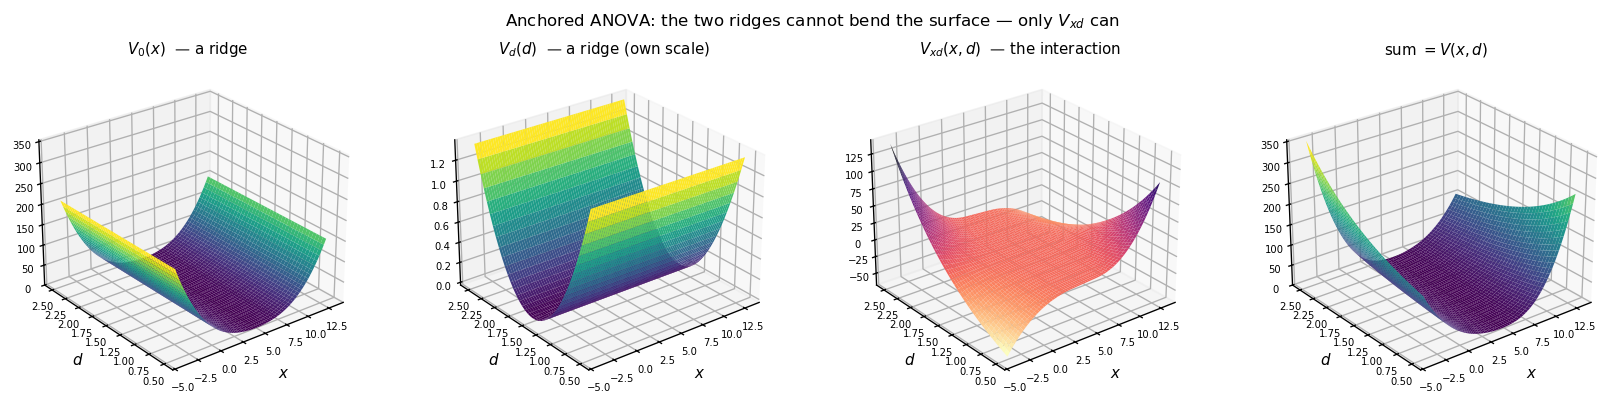

In [7]:
ELEV, AZIM = 26, -128

def surf(ax, Z, title, zlim=None, cmap="viridis"):
    ax.plot_surface(GX, GD, Z, cmap=cmap, linewidth=0, antialiased=True,
                    rstride=1, cstride=1)
    ax.set_xlabel(r"$x$", labelpad=-4); ax.set_ylabel(r"$d$", labelpad=-4)
    ax.set_title(title, fontsize=9, pad=2)
    ax.view_init(elev=ELEV, azim=AZIM)
    ax.tick_params(labelsize=6, pad=-2)
    if zlim:
        ax.set_zlim(*zlim)


zmax = float(VSTAR.max())
fig = plt.figure(figsize=(14, 3.4))
for j, (Z, t, zl, cm) in enumerate([
        (V0[:, None] + 0 * VSTAR, r"$V_0(x)$  — a ridge", (0, zmax), "viridis"),
        (Vd[None, :] + 0 * VSTAR, r"$V_d(d)$  — a ridge (own scale)", None, "viridis"),
        (Vxd, r"$V_{xd}(x,d)$  — the interaction", None, "magma_r"),
        (VSTAR, r"sum $=V(x,d)$", (0, zmax), "viridis")]):
    ax = fig.add_subplot(1, 4, j + 1, projection="3d")
    surf(ax, Z, t, zlim=zl, cmap=cm)
fig.suptitle(r"Anchored ANOVA: the two ridges cannot bend the surface — only $V_{xd}$ can", fontsize=10)
fig.tight_layout()
plt.show()

The modules are interpretable! 
- Under the nominal case (no unceratiainty), one can easily interpret the baseline module $V_0(x)$ as incurring a large cost for not being at $x_{ref} = 5$. 
- The interaction module $V_{xd}$ represents the correction due to the uncerainty, which we can interpret at incurring a large cost if our inventory is large, and demand is low, or if the inventory is small and the demand is large, which is physically meaningful.

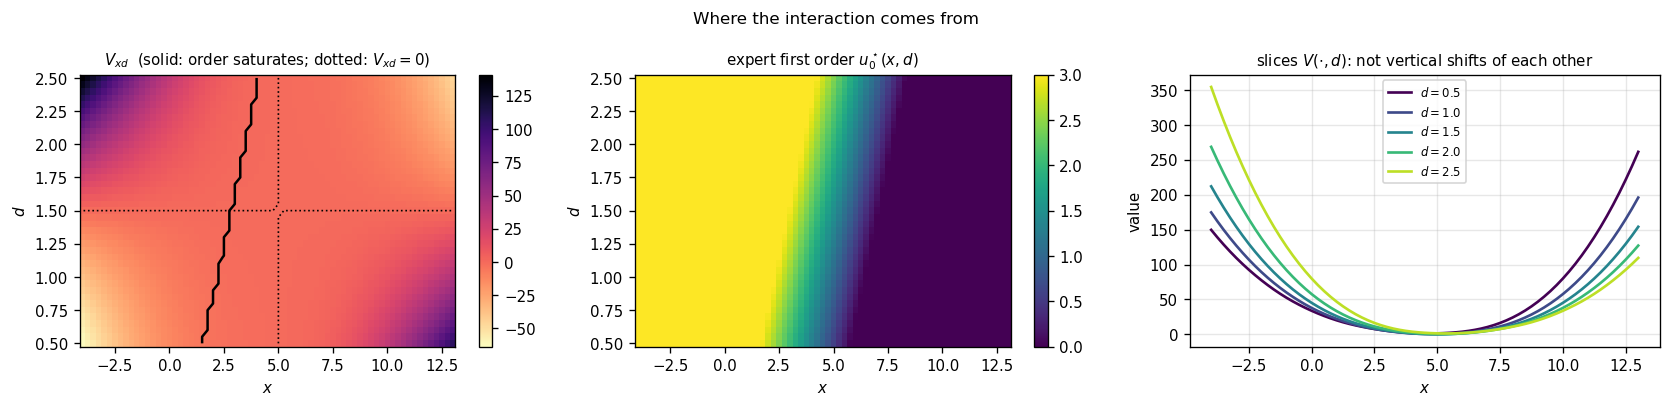

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.4))
im = ax[0].pcolormesh(GX, GD, Vxd, cmap="magma_r", shading="auto")
ax[0].contour(GX, GD, USTAR, levels=[u_max - 1e-6], colors="k", linewidths=1.5)
ax[0].contour(GX, GD, Vxd, levels=[0.0], colors="k", linestyles=":", linewidths=1.0)
ax[0].set_title(r"$V_{xd}$  (solid: order saturates; dotted: $V_{xd}=0$)", fontsize=9)
plt.colorbar(im, ax=ax[0])
im = ax[1].pcolormesh(GX, GD, USTAR, cmap="viridis", shading="auto")
ax[1].set_title(r"expert first order $u^\star_0(x,d)$", fontsize=9)
plt.colorbar(im, ax=ax[1])
for a in ax[:2]:
    a.set_xlabel(r"$x$"); a.set_ylabel(r"$d$")
for c, j in zip(plt.cm.viridis(np.linspace(0.0, 0.9, 5)), np.linspace(0, ND - 1, 5).astype(int)):
    ax[2].plot(xg, VSTAR[:, j], color=c, lw=1.6, label=fr"$d={dg[j]:.1f}$")
ax[2].set_xlabel(r"$x$"); ax[2].set_ylabel("value")
ax[2].set_title(r"slices $V(\cdot,d)$: not vertical shifts of each other", fontsize=9)
ax[2].legend(fontsize=7)
fig.suptitle("Where the interaction comes from", fontsize=10)
fig.tight_layout()
plt.show()

## 5. Learn the first-order modules from 1-D expert sweeps

$V_0$ needs the expert only along the line $d = d_0$, and $V_d$ only along $x = \bar x$. Both are **1D** regressions. Each is learned from a 1D sweep with an RBF network. The first-order modules are cheap -> each is a **1-D** regression that we can afford to fit essentially exactly.

Only the interaction has to be learned in the joint $(x,d)$ space.


In [9]:
xs1 = np.linspace(XLO, XHI, 241)
ds1 = np.linspace(DLO, DHI, 81)
t0 = time.time()
v0_tr = np.array([V_expert(z, d_0) for z in xs1])
va = V_expert(x_bar, d_0)
vd_tr = np.array([V_expert(x_bar, z) for z in ds1]) - va
print(f"1-D sweeps: {len(xs1) + len(ds1) + 1} expert solves in {time.time()-t0:.1f} s")

# inputs scaled to [-1, 1]
XC, XH = 0.5 * (XLO + XHI), 0.5 * (XHI - XLO)
DC, DH = 0.5 * (DLO + DHI), 0.5 * (DHI - DLO)
sx = lambda x: (np.atleast_1d(x) - XC) / XH
sd = lambda d: (np.atleast_1d(d) - DC) / DH

rbf_0 = RBFInterpolator(sx(xs1)[:, None], v0_tr, kernel="thin_plate_spline", smoothing=1e-10, degree=2)
rbf_d = RBFInterpolator(sd(ds1)[:, None], vd_tr, kernel="thin_plate_spline", smoothing=1e-10, degree=2)
V0_hat = lambda x: rbf_0(sx(x)[:, None])
Vd_hat = lambda d: rbf_d(sd(d)[:, None])

rg = np.random.default_rng(7)
zt = rg.uniform(XLO, XHI, 100); vt = np.array([V_expert(z, d_0) for z in zt])
ee = np.abs(V0_hat(zt) - vt) / vt
print(f"V0_hat: 1-D fit from {len(xs1)} points, median rel.err {np.median(ee):.2e}, max {ee.max():.2e}")
zt = rg.uniform(DLO, DHI, 100); vt = np.array([V_expert(x_bar, z) for z in zt]) - va
ee = np.abs(Vd_hat(zt) - vt)
print(f"Vd_hat: 1-D fit from {len(ds1)} points, median abs.err {np.median(ee):.2e}, max {ee.max():.2e}"
      f"   (Vd ranges over 0 .. {vt.max():.2f})")

1-D sweeps: 323 expert solves in 1.0 s
V0_hat: 1-D fit from 241 points, median rel.err 2.42e-07, max 5.08e-05
Vd_hat: 1-D fit from 81 points, median abs.err 1.11e-16, max 1.33e-15   (Vd ranges over 0 .. 1.34)


## 6. Learn the interaction as another module

We query the expert at $n$ points in the joint space (a coarse grid on the two demand edges, so that no fit has to extrapolate, plus random points) and fit an RBF network to the residual

$$V(x,d) - \hat V_0(x) - \hat V_d(d).$$

The interaction vanishes on the anchor cross by construction, so the 1-D sweep points enter this fit with target zero, at no extra cost.

For comparison, a **monolithic** RBF network $\hat V(x,d)$ is fitted to the same expert data: the $n$ joint samples and the 1-D sweeps.

In [10]:
def joint_samples(n, seed):
    # a 5x2 grid on the demand edges (no extrapolation), topped up with uniform random points
    bx, bd = np.meshgrid(np.linspace(XLO, XHI, 5), [DLO, DHI])
    rg = np.random.default_rng(seed)
    m = n - bx.size
    return (np.concatenate([bx.ravel(), rg.uniform(XLO, XHI, m)]),
            np.concatenate([bd.ravel(), rg.uniform(DLO, DHI, m)]))


# the 1-D sweeps, as points in the joint space
XCROSS = np.concatenate([xs1, np.full(ds1.size, x_bar)])
DCROSS = np.concatenate([np.full(xs1.size, d_0), ds1])
VCROSS = np.concatenate([v0_tr, vd_tr + va])
sxd = lambda x, d: np.column_stack([sx(x), sd(d)])


def fit_modular(xs, ds, vs):
    res = vs - V0_hat(xs) - Vd_hat(ds)
    rbf = RBFInterpolator(np.vstack([sxd(xs, ds), sxd(XCROSS, DCROSS)]),
                          np.concatenate([res, np.zeros(XCROSS.size)]),
                          kernel="thin_plate_spline", smoothing=1e-8, degree=1)
    return lambda x, d: rbf(sxd(x, d))


def fit_monolithic(xs, ds, vs):
    rbf = RBFInterpolator(np.vstack([sxd(xs, ds), sxd(XCROSS, DCROSS)]),
                          np.concatenate([vs, VCROSS]),
                          kernel="thin_plate_spline", smoothing=1e-8, degree=2)
    return lambda x, d: rbf(sxd(x, d))


N_JOINT = 200
xs2, ds2 = joint_samples(N_JOINT, seed=1)
t0 = time.time()
vs2 = np.array([V_expert(x, d) for x, d in zip(xs2, ds2)])
print(f"joint samples: {N_JOINT} expert solves in {time.time()-t0:.1f} s")

Vxd_hat = fit_modular(xs2, ds2, vs2)
V_mono_hat = fit_monolithic(xs2, ds2, vs2)
e = np.abs(Vxd_hat(GX.ravel(), GD.ravel()).reshape(GX.shape) - Vxd)
print(f"Vxd_hat: abs. error on the grid  median {np.median(e):.2e}   max {e.max():.2e}"
      f"   (Vxd ranges over {Vxd.min():.1f} .. {Vxd.max():.1f})")

joint samples: 200 expert solves in 0.6 s
Vxd_hat: abs. error on the grid  median 3.19e-02   max 4.95e+00   (Vxd ranges over -63.7 .. 141.0)


##  Verify the modular composition

We compare three terminal costs against the expert on the full grid: the modular reconstruction, the monolithic fit, and the additive fit without the interaction module.

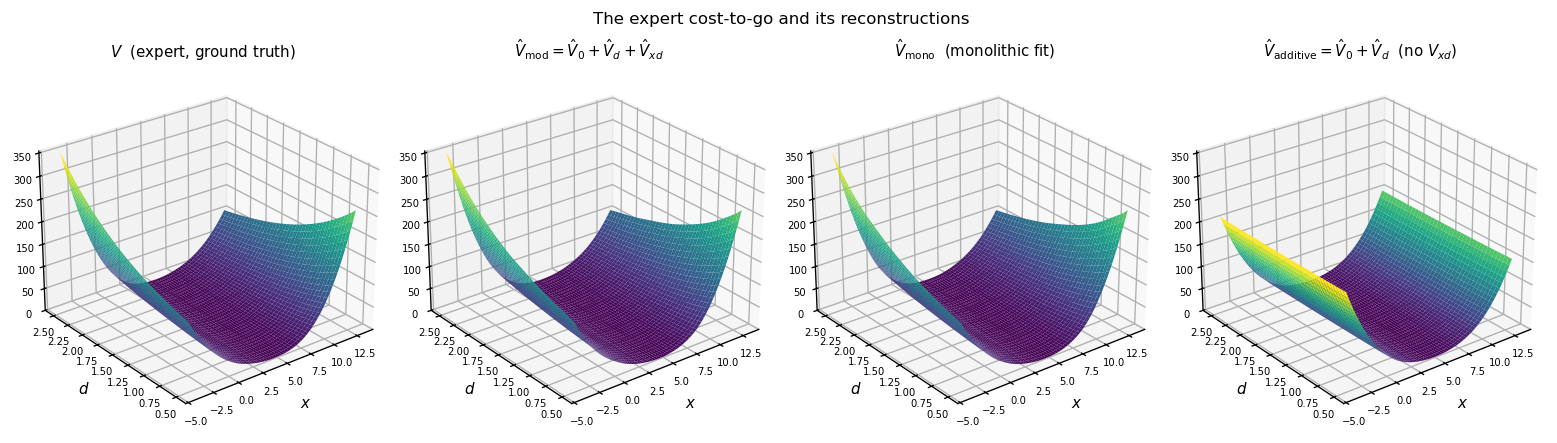

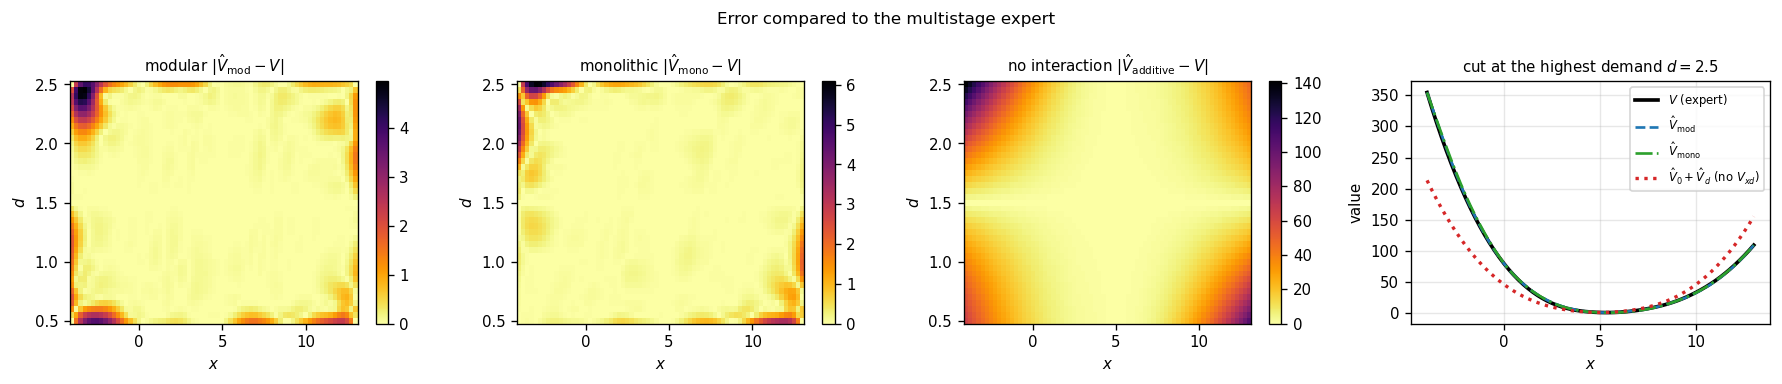

In [11]:
V0_G  = V0_hat(GX.ravel()).reshape(GX.shape)
Vd_G  = Vd_hat(GD.ravel()).reshape(GX.shape)
SMOD  = V0_G + Vd_G + Vxd_hat(GX.ravel(), GD.ravel()).reshape(GX.shape)   # modular reconstruction
SMONO = V_mono_hat(GX.ravel(), GD.ravel()).reshape(GX.shape)              # monolithic fit
SADD  = V0_G + Vd_G                                                       # no interaction module

zl = (0, float(VSTAR.max()))
fig = plt.figure(figsize=(13, 3.8))
for j, (Z, t) in enumerate([
        (VSTAR, r"$V$  (expert, ground truth)"),
        (SMOD, r"$\hat V_{\rm mod}=\hat V_0+\hat V_d+\hat V_{xd}$"),
        (SMONO, r"$\hat V_{\rm mono}$  (monolithic fit)"),
        (SADD, r"$\hat V_{\rm additive}=\hat V_0+\hat V_d$  (no $V_{xd}$)")]):
    ax = fig.add_subplot(1, 4, j + 1, projection="3d")
    surf(ax, Z, t, zlim=zl)
fig.suptitle("The expert cost-to-go and its reconstructions", fontsize=10)
fig.tight_layout()
plt.show()

E_MOD, E_MONO, E_ADD = np.abs(SMOD - VSTAR), np.abs(SMONO - VSTAR), np.abs(SADD - VSTAR)
fig, ax = plt.subplots(1, 4, figsize=(15, 3.2))
for a, (E, t) in zip(ax[:3], [(E_MOD, r"modular $|\hat V_{\rm mod}-V|$"),
                              (E_MONO, r"monolithic $|\hat V_{\rm mono}-V|$"),
                              (E_ADD, r"no interaction $|\hat V_{\rm additive}-V|$")]):
    im = a.pcolormesh(GX, GD, E, cmap="inferno_r", shading="auto")
    a.set_xlabel(r"$x$"); a.set_ylabel(r"$d$"); a.set_title(t, fontsize=9)
    plt.colorbar(im, ax=a)
jc = ND - 1
ax[3].plot(xg, VSTAR[:, jc], "k-", lw=2.2, label=r"$V$ (expert)")
ax[3].plot(xg, SMOD[:, jc], "--", color="tab:blue", lw=1.6, label=r"$\hat V_{\rm mod}$")
ax[3].plot(xg, SMONO[:, jc], "-.", color="tab:green", lw=1.6, label=r"$\hat V_{\rm mono}$")
ax[3].plot(xg, SADD[:, jc], ":", color="tab:red", lw=2.0, label=r"$\hat V_0+\hat V_d$ (no $V_{xd}$)")
ax[3].set_xlabel(r"$x$"); ax[3].set_ylabel("value")
ax[3].set_title(fr"cut at the highest demand $d={dg[jc]:g}$", fontsize=9)
ax[3].legend(fontsize=7)
fig.suptitle("Error compared to the multistage expert", fontsize=10)
fig.tight_layout()
plt.show()

## 7. From cost-to-go to policy: 1-step MPC vs the expert

The decisive test. Each cost-to-go is used as the terminal cost of the 1-step MPC from Section 2, and its first order is compared with the expert's own first order on 200 test states.

In [12]:
full = lambda xp, d: np.full(np.size(xp), d)
terminal_costs = {
    "expert grid  V (interpolated)": V_grid,
    "V0 only  (d-ignorant)":         lambda xp, d: V0_hat(xp),
    "V0 + Vd  (additive)":           lambda xp, d: V0_hat(xp) + Vd_hat(full(xp, d)),
    "V0 + Vd + Vxd  (modular)":      lambda xp, d: V0_hat(xp) + Vd_hat(full(xp, d)) + Vxd_hat(xp, full(xp, d)),
    "V  (monolithic)":               lambda xp, d: V_mono_hat(xp, full(xp, d)),
}


def policy_error(Vfun):
    u = np.array([onestep(x, d, Vfun)[0] for x, d in zip(XS_TEST, DS_TEST)])
    return u - U_TEST


ERR = {k: policy_error(f) for k, f in terminal_costs.items()}
print(f"{'terminal cost':32s} {'rms |u - u*|':>13s} {'max |u - u*|':>13s} {'rms, % of u_max':>16s}")
for k, e in ERR.items():
    print(f"{k:32s} {rms(e):13.4f} {np.abs(e).max():13.4f} {100 * rms(e) / u_max:16.2f}")
print("\nV0 only and V0 + Vd give identical orders: Vd adds a constant to the 1-step objective.")

terminal cost                     rms |u - u*|  max |u - u*|  rms, % of u_max
expert grid  V (interpolated)           0.0004        0.0013             0.01
V0 only  (d-ignorant)                   0.0685        0.1981             2.28
V0 + Vd  (additive)                     0.0685        0.1981             2.28
V0 + Vd + Vxd  (modular)                0.0067        0.0328             0.22
V  (monolithic)                         0.0064        0.0347             0.21

V0 only and V0 + Vd give identical orders: Vd adds a constant to the 1-step objective.


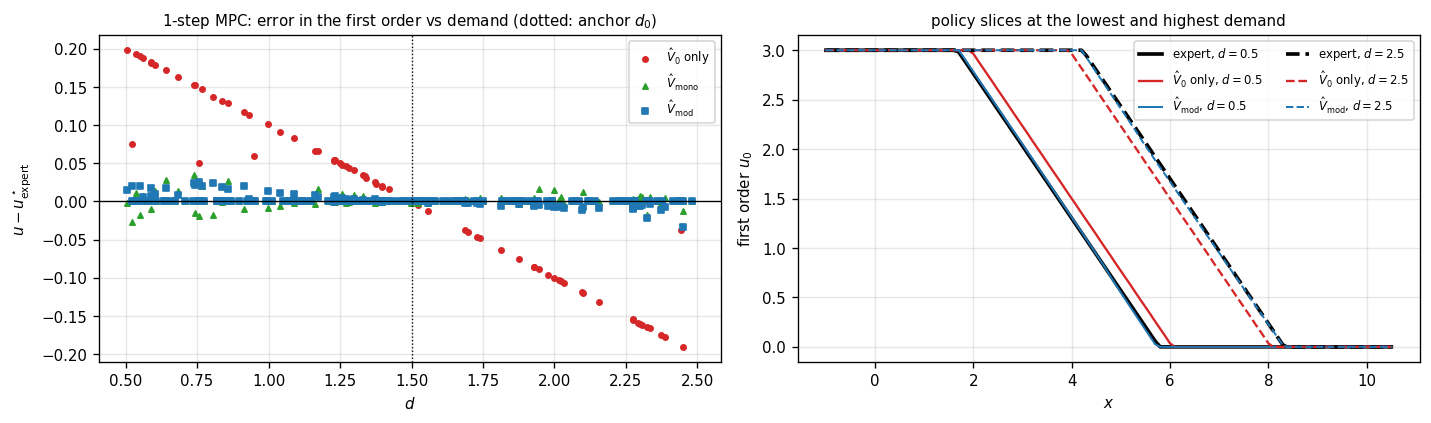

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
for k, c, mk, lab in [("V0 only  (d-ignorant)", "tab:red", "o", r"$\hat V_0$ only"),
                      ("V  (monolithic)", "tab:green", "^", r"$\hat V_{\rm mono}$"),
                      ("V0 + Vd + Vxd  (modular)", "tab:blue", "s", r"$\hat V_{\rm mod}$")]:
    ax[0].scatter(DS_TEST, ERR[k], s=10, color=c, marker=mk, label=lab)
ax[0].axhline(0.0, color="k", lw=0.8); ax[0].axvline(d_0, color="k", ls=":", lw=0.8)
ax[0].set_xlabel(r"$d$"); ax[0].set_ylabel(r"$u - u^\star_{\rm expert}$")
ax[0].set_title("1-step MPC: error in the first order vs demand (dotted: anchor $d_0$)", fontsize=9)
ax[0].legend(fontsize=7)

xx = np.linspace(-1.0, 10.5, 116)
for dv, ls in [(DLO, "-"), (DHI, "--")]:
    ax[1].plot(xx, [V_expert(x, dv, want_u=True)[1][0] for x in xx], ls, color="k", lw=2.2,
               label=fr"expert, $d={dv:g}$")
    ax[1].plot(xx, [onestep(x, dv, terminal_costs["V0 only  (d-ignorant)"])[0] for x in xx], ls,
               color="tab:red", lw=1.4, label=fr"$\hat V_0$ only, $d={dv:g}$")
    ax[1].plot(xx, [onestep(x, dv, terminal_costs["V0 + Vd + Vxd  (modular)"])[0] for x in xx], ls,
               color="tab:blue", lw=1.2, label=fr"$\hat V_{{\rm mod}}$, $d={dv:g}$")
ax[1].set_xlabel(r"$x$"); ax[1].set_ylabel(r"first order $u_0$")
ax[1].set_title(r"policy slices at the lowest and highest demand", fontsize=9)
ax[1].legend(fontsize=7, ncol=2)
fig.tight_layout()
plt.show()

## Summary


* The anchored ANOVA identity is exact. The first-order modules are **1D** regressions on the anchor cross, fitted essentially exactly from 1D expert sweeps. The demand-only module $V_d$ is negligible and cannot affect the decision.
* With an uncertain, time-varying demand, the interaction $V_{xd}$ is what the controller needs.
* What this does not show: this is a two-variable problem, so it demonstrates the mechanism, not scaling. Adjustable risk profiles, and robust stability and feasibiliy are open problems that we aim to address in the project. 